# 01 Exploratory Data Analysis

Initial data loading, title cleaning, class balance checks, title-length summaries, token counts, and word/bigram frequency plots.


In [ ]:
# Keep paths stable whether this notebook is run from the repo root or from notebooks/.
from pathlib import Path
import os
import sys

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from performance_landscapes.data import balanced_subset, clean_title_rows, load_raw_news_data
from performance_landscapes.eda import (
    clean_tokenize,
    count_bigrams_by_class,
    count_tokens_by_class,
    get_bigrams,
    plot_top_bigrams,
    plot_top_words,
    simple_tokenize,
)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


In [4]:
# Load and combine data
# Labels: fake = 1, real = 0
df = load_raw_news_data()

print("Combined shape:", df.shape)
print(df["label"].value_counts())


Combined shape: (44898, 5)
label
1    23481
0    21417
Name: count, dtype: int64


In [5]:
# Keep title only
df = clean_title_rows(df)

print("Shape after removing empty titles:", df.shape)


Shape after removing empty titles: (44898, 5)


In [6]:
# Optional subset for speed
subset_size = 10000

df = balanced_subset(df, subset_size=subset_size, random_state=42)

print("Shape after optional subsetting:", df.shape)
print(df["label"].value_counts())


Shape after optional subsetting: (10000, 5)
label
1    5000
0    5000
Name: count, dtype: int64


# Exploratory Data Analysis

In [ ]:
# NOTE: Not everything in this section was included in the final report. Most of this was to get an idea of what the data looked like. 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re

In [44]:
# Make sure title exists and is clean
df["title"] = df["title"].fillna("").astype(str).str.strip()

# Remove empty titles
df_eda = df[df["title"].str.len() > 0].copy()

print("Dataset shape:", df_eda.shape)
print("\nClass counts:")
print(df_eda["label"].value_counts())

# Nice table
class_summary = (
    df_eda["label"]
    .value_counts()
    .rename(index={0: "Real", 1: "Fake"})
    .reset_index()
)
class_summary.columns = ["Class", "Count"]
class_summary["Percent"] = 100 * class_summary["Count"] / class_summary["Count"].sum()

print("\nClass summary:")
print(class_summary)

Dataset shape: (10000, 5)

Class counts:
label
1    5000
0    5000
Name: count, dtype: int64

Class summary:
  Class  Count  Percent
0  Fake   5000     50.0
1  Real   5000     50.0


In [46]:
df_eda["title_char_length"] = df_eda["title"].str.len()
df_eda["title_word_count"] = df_eda["title"].str.split().apply(len)

length_summary = (
    df_eda.groupby("label")[["title_char_length", "title_word_count"]]
    .agg(["mean", "median", "std", "min", "max"])
)

print("\nTitle length summary by class:")
print(length_summary)


Title length summary by class:
      title_char_length                            title_word_count         \
                   mean median        std min  max             mean median   
label                                                                        
0               64.6168   64.0   8.951178  33  105           9.9654   10.0   
1               93.6012   88.0  27.599408   8  276          14.6992   14.0   

                         
            std min max  
label                    
0      1.661552   5  17  
1      4.408924   1  42  


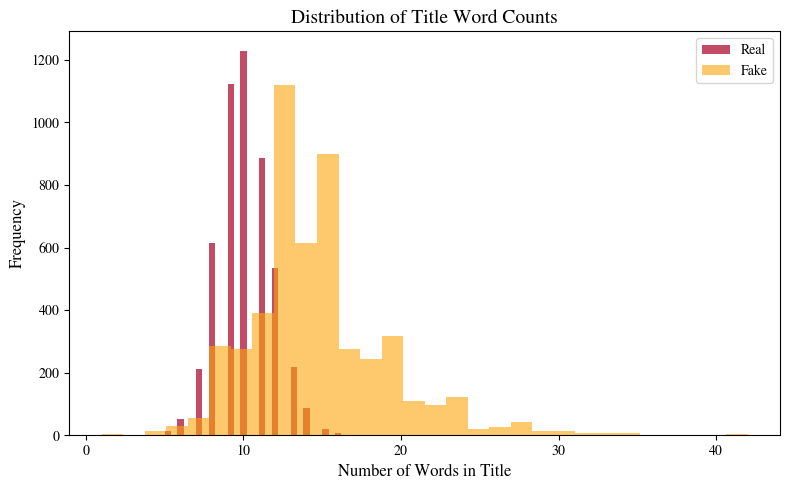

In [57]:
cmap = plt.get_cmap("inferno")
real_color = cmap(0.5)
fake_color = cmap(0.8)

plt.figure(figsize=(8, 5))

plt.hist(
    df_eda[df_eda["label"] == 0]["title_word_count"],
    bins=30,
    alpha=0.9,
    label="Real",
    color=real_color
)

plt.hist(
    df_eda[df_eda["label"] == 1]["title_word_count"],
    bins=30,
    alpha=0.6,
    label="Fake",
    color=fake_color
)

plt.title("Distribution of Title Word Counts")
plt.xlabel("Number of Words in Title")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

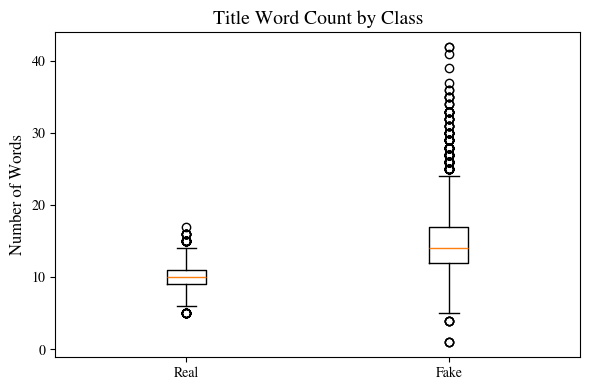

In [59]:
plt.figure(figsize=(6, 4))
plt.boxplot(
    [
        df_eda[df_eda["label"] == 0]["title_word_count"],
        df_eda[df_eda["label"] == 1]["title_word_count"]
    ],
    labels=["Real", "Fake"]
)
plt.title("Title Word Count by Class")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

In [ ]:
# Tokenization helpers are imported from performance_landscapes.eda.


In [64]:
all_tokens = []
real_tokens = []
fake_tokens = []

for title in df_eda["title"]:
    all_tokens.extend(simple_tokenize(title))

for title in df_eda[df_eda["label"] == 0]["title"]:
    real_tokens.extend(simple_tokenize(title))

for title in df_eda[df_eda["label"] == 1]["title"]:
    fake_tokens.extend(simple_tokenize(title))

print("Overall vocabulary size:", len(set(all_tokens)))
print("Real-title vocabulary size:", len(set(real_tokens)))
print("Fake-title vocabulary size:", len(set(fake_tokens)))

Overall vocabulary size: 12240
Real-title vocabulary size: 7068
Fake-title vocabulary size: 8866


In [65]:
from collections import Counter

real_tokens = []
fake_tokens = []

for title in df_eda[df_eda["label"] == 0]["title"]:
    real_tokens.extend(clean_tokenize(title))

for title in df_eda[df_eda["label"] == 1]["title"]:
    fake_tokens.extend(clean_tokenize(title))

real_counter = Counter(real_tokens)
fake_counter = Counter(fake_tokens)

print("\nTop 20 words in real titles:")
print(real_counter.most_common(20))

print("\nTop 20 words in fake titles:")
print(fake_counter.most_common(20))


Top 20 words in real titles:
[('trump', 1108), ('says', 708), ('house', 357), ('north', 208), ('new', 206), ('white', 195), ('russia', 195), ('korea', 187), ('court', 174), ('state', 168), ('senate', 166), ('trumps', 162), ('china', 150), ('republican', 150), ('obama', 147), ('tax', 143), ('clinton', 141), ('eu', 132), ('deal', 132), ('vote', 131)]

Top 20 words in fake titles:
[('video', 1796), ('trump', 1665), ('hillary', 429), ('obama', 406), ('watch', 398), ('trumps', 325), ('just', 324), ('president', 242), ('new', 219), ('clinton', 212), ('black', 192), ('donald', 181), ('breaking', 179), ('white', 178), ('gop', 162), ('news', 157), ('media', 143), ('muslim', 138), ('gets', 134), ('america', 132)]


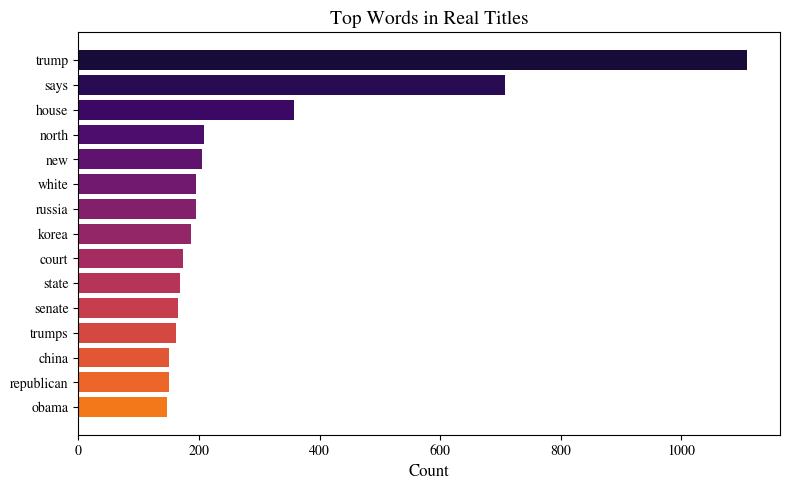

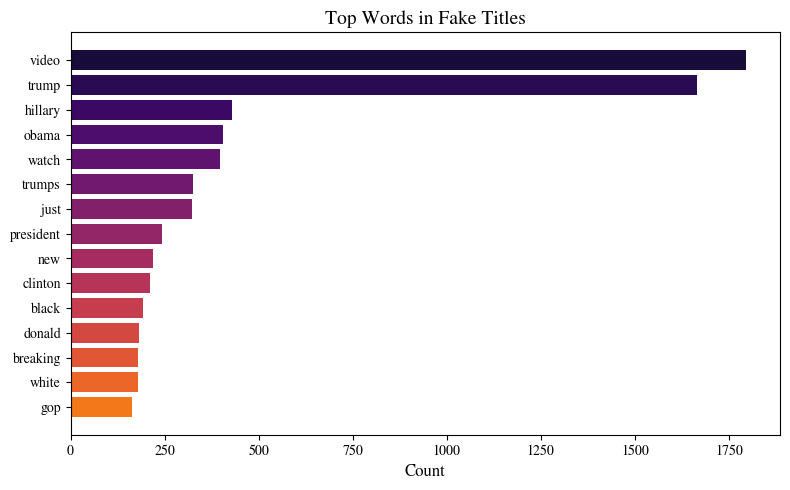

In [73]:
def plot_top_words(counter, title, n=15):
    top_words = counter.most_common(n)
    words = [w for w, c in top_words]
    counts = [c for w, c in top_words]

    plt.figure(figsize=(8, 5))
    plt.barh(words[::-1], counts[::-1], color = tuple(cmap(x) for x in np.linspace(0.7, 0.1, 15)))
    plt.title(title)
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

plot_top_words(real_counter, "Top Words in Real Titles", n=15)
plot_top_words(fake_counter, "Top Words in Fake Titles", n=15)

In [ ]:
def get_bigrams(tokens):
    return list(zip(tokens, tokens[1:]))

real_bigrams = []
fake_bigrams = []

for title in df_eda[df_eda["label"] == 0]["title"]:
    tokens = simple_tokenize(title)
    real_bigrams.extend(get_bigrams(tokens))

for title in df_eda[df_eda["label"] == 1]["title"]:
    tokens = simple_tokenize(title)
    fake_bigrams.extend(get_bigrams(tokens))

real_bigram_counter = Counter(real_bigrams)
fake_bigram_counter = Counter(fake_bigrams)

print("\nTop 15 bigrams in real titles:")
print(real_bigram_counter.most_common(15))

print("\nTop 15 bigrams in fake titles:")
print(fake_bigram_counter.most_common(15))


Top 15 bigrams in real titles:
[(('white', 'house'), 186), (('north', 'korea'), 146), (('trump', 'says'), 87), (('islamic', 'state'), 67), (('supreme', 'court'), 59), (('travel', 'ban'), 39), (('south', 'korea'), 38), (('attorney', 'general'), 36), (('house', 'speaker'), 35), (('puerto', 'rico'), 31), (('factbox', 'trump'), 29), (('new', 'york'), 27), (('north', 'korean'), 27), (('trump', 'administration'), 26), (('state', 'department'), 26)]

Top 15 bigrams in fake titles:
[(('donald', 'trump'), 154), (('president', 'trump'), 91), (('white', 'house'), 81), (('hillary', 'clinton'), 64), (('trump', 'video'), 62), (('bernie', 'sanders'), 60), (('anti', 'trump'), 58), (('fox', 'news'), 57), (('trump', 'supporter'), 53), (('boiler', 'room'), 47), (('trump', 'supporters'), 47), (('ted', 'cruz'), 42), (('trump', 'just'), 41), (('fake', 'news'), 39), (('president', 'obama'), 38)]


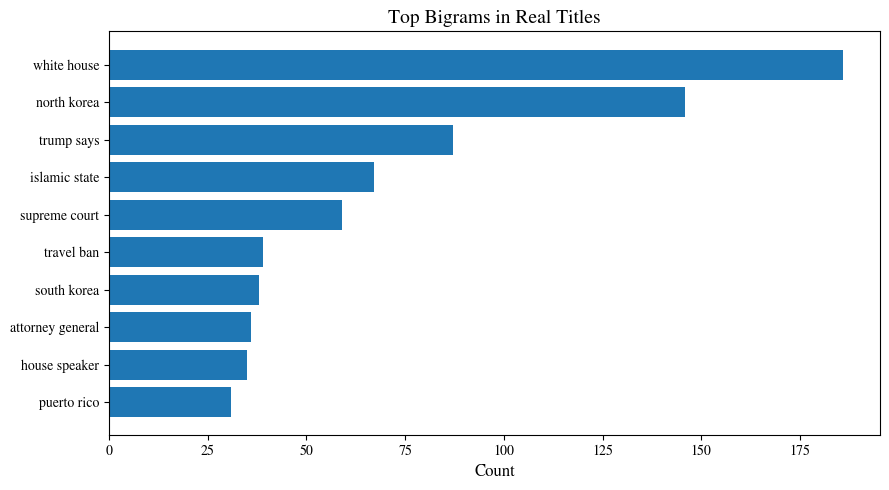

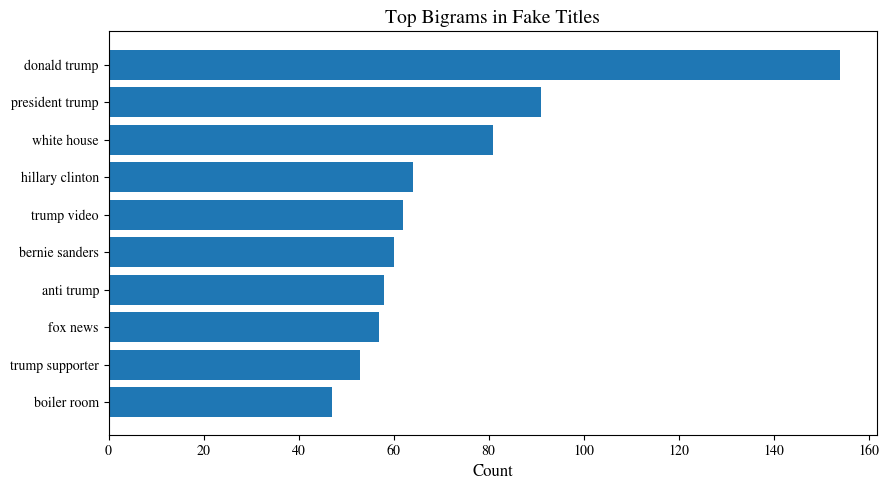

In [ ]:
def plot_top_bigrams(counter, title, n=10):
    top_bigrams = counter.most_common(n)
    labels = [" ".join(bg) for bg, c in top_bigrams]
    counts = [c for bg, c in top_bigrams]

    plt.figure(figsize=(9, 5))
    plt.barh(labels[::-1], counts[::-1])
    plt.title(title)
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

plot_top_bigrams(real_bigram_counter, "Top Bigrams in Real Titles", n=10)
plot_top_bigrams(fake_bigram_counter, "Top Bigrams in Fake Titles", n=10)